# Application Notebook: Transmon readout analysis with branch analysis

In this notebook, we apply branch analysis to a transmon-resonator system with a readout-oriented question.

Goals:

1. build a transmon + resonator Hamiltonian,
2. inspect dressed-state composition,
3. assign branch labels using `ordering="LX"`,
4. identify where bare-like branch structure starts to weaken,
5. diagnose near-resonant branch mixing that can matter for readout.

In [3]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

## Step 1. Define subsystem parameters

We choose a transmon plus readout resonator with several retained transmon levels,
since higher levels are essential for branch-mixing diagnostics.

In [133]:
EJ = 22.0
EC = 0.28
ng = 0.0

tmon = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=ng,
    ncut=45,
    truncated_dim=6
)

res = scq.Oscillator(
    E_osc=7.0,
    truncated_dim=18
)

## Step 2. Build the composite Hilbert space

We couple the transmon charge operator to the resonator quadrature.
This is the natural first model for a capacitively coupled transmon-resonator system.

In [134]:
hs = scq.HilbertSpace([tmon, res])

g = 0.11

hs.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
    )


## Step 3. Diagonalize the full interacting Hamiltonian

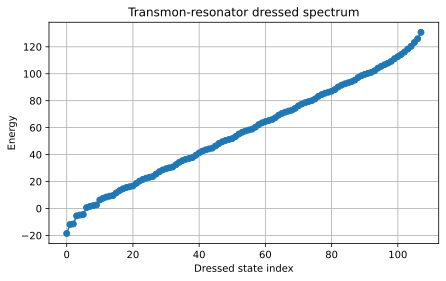

In [135]:
evals_count = 108
evals, evecs = hs.eigensys(evals_count=evals_count)

plt.figure(figsize=(7,4))
plt.plot(range(evals_count), evals, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Energy")
plt.title("Transmon-resonator dressed spectrum")
plt.grid(True)
plt.show()

This gives
1. evals[k] → dressed energy $E_k$
2. evecs[k] → dressed eigenstate

$H |\psi_k\rangle = E_k |\psi_k\rangle$

evecs is a list of QuTiP state vectors, not a matrix.

## Step 4. Define bare product labels

Bare labels are:
(j, n)

where:
- j is the retained transmon eigenstate index
- n is the resonator Fock-state index

In [136]:
N_q = tmon.truncated_dim
N_r = res.truncated_dim

bare_labels = []
for j in range(N_q):
    for n in range(N_r):
        bare_labels.append((j, n))

In [137]:
print(bare_labels)

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (3, 17), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15), (4, 16), (4, 17), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17)]


## Step 5. Inspect dressed-state decomposition

In [138]:
overlap_table = np.abs(np.array([evecs[i].full().flatten() for i in range(len(evecs))]))**2

def print_top_components(dressed_index, top_n=10):
    probs = overlap_table[:, dressed_index]
    order = np.argsort(probs)[::-1]
    print(f"dressed state {dressed_index}, energy = {evals[dressed_index]:.6f}")
    for idx in order[:top_n]:
        print(f"  bare {bare_labels[idx]}: {probs[idx]:.6f}")

This computes

$$
\left|\left\langle j, n \mid \psi_k\right\rangle\right|^2
$$

so `overlap_table[basis_index, dressed_state]` gives the probability that dressed state $k$ containts bare state $(j, n)$.

In [139]:
print_top_components(0)
print()
print_top_components(5)
print()
print_top_components(12)

dressed state 0, energy = -18.562827
  bare (0, 0): 0.999903
  bare (0, 4): 0.000066
  bare (0, 5): 0.000021
  bare (0, 3): 0.000009
  bare (0, 12): 0.000000
  bare (0, 11): 0.000000
  bare (0, 13): 0.000000
  bare (0, 10): 0.000000
  bare (0, 14): 0.000000
  bare (1, 3): 0.000000

dressed state 5, energy = -4.459389
  bare (1, 2): 0.579261
  bare (1, 1): 0.391911
  bare (1, 0): 0.028013
  bare (0, 17): 0.000235
  bare (1, 14): 0.000225
  bare (1, 12): 0.000189
  bare (1, 13): 0.000149
  bare (1, 11): 0.000016
  bare (0, 16): 0.000000
  bare (1, 10): 0.000000

dressed state 12, energy = 8.511974
  bare (3, 7): 0.498072
  bare (3, 8): 0.393236
  bare (3, 6): 0.103836
  bare (3, 5): 0.003572
  bare (4, 2): 0.000543
  bare (4, 0): 0.000516
  bare (3, 17): 0.000109
  bare (4, 1): 0.000083
  bare (3, 4): 0.000026
  bare (3, 16): 0.000005


## Step 6. Compare DE and LX labeling

According to the scqubits, overlap-based labeling can fail in non-dispersive cases,
and branch analysis via `ordering="LX"` is meant to fix this. 

In [140]:
hs.generate_lookup(ordering="DE")
print("Generated DE lookup")
print([name for name in dir(hs) if "lookup" in name.lower() or "index" in name.lower()])
for name in ["lookup", "_lookup"]:
    if hasattr(hs, name):
        print(f"\n{name} under DE:")
        print(getattr(hs, name))

Generated DE lookup
['_generate_lookup_by_overlap', '_lookup_exists', 'bare_index', 'dressed_index', 'energy_by_bare_index', 'energy_by_dressed_index', 'generate_lookup', 'get_subsys_index', 'lookup_exists', 'set_npindextuple']


In [141]:
hs.generate_lookup(ordering="LX")
print("Generated LX lookup")
for name in ["lookup", "_lookup"]:
    if hasattr(hs, name):
        print(f"\n{name} under LX:")
        print(getattr(hs, name))

Generated LX lookup


DE answers:

- What bare state does this eigenstate mostly look like?

LX answers:

- Which excitation branch does this eigenstate belong to?


## Step 7. Largest bare-component probability

For each dressed state, compute the largest bare-state probability.
If this is close to 1, the state is nearly bare-like.
If it is lower, the state is more strongly hybridized.

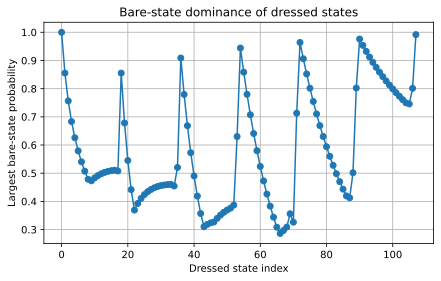

In [ ]:
max_probs = [np.max(overlap_table[:, k]) for k in range(evals_count)] # Largest bare-state probability for each dressed state

plt.figure(figsize=(7,4))
plt.plot(range(evals_count), max_probs, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Largest bare-state probability")
plt.title("Bare-state dominance of dressed states")
plt.grid(True)
plt.show()

## Step 8. Estimate branch purity as a function of photon number

For a readout application, the important question is not just whether a state is mixed,
but whether the branch connected to a low transmon level remains identifiable as photon number increases.

In [143]:
def branch_purity_for_transmon_level(level, photon_cut=12):
    purities = []
    winning_states = []

    for n in range(photon_cut):
        target_flat = level * N_r + n
        bare_vec = np.zeros(N_q * N_r)
        bare_vec[target_flat] = 1.0

        overlaps = [np.abs(np.vdot(evecs[k], bare_vec))**2 for k in range(evals_count)]
        best_k = int(np.argmax(overlaps))
        purities.append(overlaps[best_k])
        winning_states.append(best_k)

    return np.array(purities), np.array(winning_states)

purity_g, states_g = branch_purity_for_transmon_level(level=0, photon_cut=12)
purity_e, states_e = branch_purity_for_transmon_level(level=1, photon_cut=12)

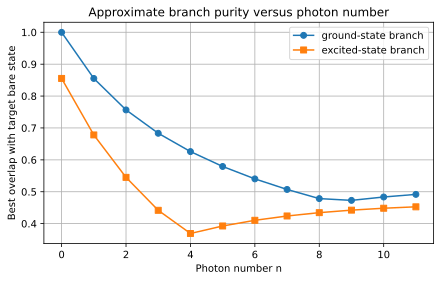

In [144]:
plt.figure(figsize=(7,4))
plt.plot(range(12), purity_g, marker='o', label='ground-state branch')
plt.plot(range(12), purity_e, marker='s', label='excited-state branch')
plt.xlabel("Photon number n")
plt.ylabel("Best overlap with target bare state")
plt.title("Approximate branch purity versus photon number")
plt.grid(True)
plt.legend()
plt.show()

Interpretation:

If these curves stay near 1, branch identity remains robust.
If they drop substantially, that means the bare-state-connected branch is becoming ambiguous or strongly hybridized.

In [153]:
print("purity_g:", purity_g)
print("purity_e:", purity_e)

purity_g: [0.99990345 0.85527405 0.75661369 0.68332738 0.62591294 0.57926146
 0.54033332 0.5071844  0.47850181 0.47294283 0.48350153 0.49172758]
purity_e: [0.85527167 0.67814527 0.54511085 0.44172785 0.36913235 0.39260824
 0.41039895 0.42398265 0.43437627 0.44230293 0.44829093 0.45273496]


## Step 9. Search for near-resonant bare-state pairs

One practical way to find candidate leakage channels is to search for bare-state pairs
whose uncoupled energies are unusually close.

In [145]:
tmon_evals = tmon.eigenvals(evals_count=N_q)
res_evals = np.arange(N_r) * res.E_osc

bare_energies = {}
for j in range(N_q):
    for n in range(N_r):
        bare_energies[(j, n)] = tmon_evals[j] + res_evals[n]

pairs = []
labels = list(bare_energies.keys())

for a in range(len(labels)):
    for b in range(a + 1, len(labels)):
        l1 = labels[a]
        l2 = labels[b]
        delta = abs(bare_energies[l1] - bare_energies[l2])
        pairs.append((delta, l1, l2))

pairs_sorted = sorted(pairs, key=lambda x: x[0])

In [146]:
print("Closest bare-state near-resonances:")
for delta, l1, l2 in pairs_sorted[:20]:
    print(f"{l1}  <->  {l2}   delta = {delta:.6f}")

Closest bare-state near-resonances:
(0, 1)  <->  (1, 0)   delta = 0.272572
(0, 2)  <->  (1, 1)   delta = 0.272572
(0, 3)  <->  (1, 2)   delta = 0.272572
(0, 4)  <->  (1, 3)   delta = 0.272572
(0, 5)  <->  (1, 4)   delta = 0.272572
(0, 6)  <->  (1, 5)   delta = 0.272572
(0, 7)  <->  (1, 6)   delta = 0.272572
(0, 8)  <->  (1, 7)   delta = 0.272572
(0, 9)  <->  (1, 8)   delta = 0.272572
(0, 10)  <->  (1, 9)   delta = 0.272572
(0, 11)  <->  (1, 10)   delta = 0.272572
(0, 12)  <->  (1, 11)   delta = 0.272572
(0, 13)  <->  (1, 12)   delta = 0.272572
(0, 14)  <->  (1, 13)   delta = 0.272572
(0, 15)  <->  (1, 14)   delta = 0.272572
(0, 16)  <->  (1, 15)   delta = 0.272572
(0, 17)  <->  (1, 16)   delta = 0.272572
(1, 1)  <->  (2, 0)   delta = 0.583592
(1, 2)  <->  (2, 1)   delta = 0.583592
(1, 3)  <->  (2, 2)   delta = 0.583592


These are candidate locations where dressed-state mixing may become strong.
They are not yet the full answer, but they tell you where to inspect branch structure carefully.

## Step 10. Pick a suspicious near-resonant pair and inspect the relevant dressed states

In [147]:
candidate_1 = pairs_sorted[0][1]
candidate_2 = pairs_sorted[0][2]

print("Candidate pair:", candidate_1, candidate_2)

idx1 = candidate_1[0] * N_r + candidate_1[1]
idx2 = candidate_2[0] * N_r + candidate_2[1]

bare_vec_1 = np.zeros(N_q * N_r)
bare_vec_2 = np.zeros(N_q * N_r)
bare_vec_1[idx1] = 1.0
bare_vec_2[idx2] = 1.0

overlaps_1 = np.array([np.abs(np.vdot(evecs[k], bare_vec_1))**2 for k in range(evals_count)])
overlaps_2 = np.array([np.abs(np.vdot(evecs[k], bare_vec_2))**2 for k in range(evals_count)])

print("Best dressed match for first label:", np.argmax(overlaps_1), np.max(overlaps_1))
print("Best dressed match for second label:", np.argmax(overlaps_2), np.max(overlaps_2))

Candidate pair: (0, 1) (1, 0)
Best dressed match for first label: 2 0.855274053922282
Best dressed match for second label: 1 0.855271670847164


In [148]:
k1 = int(np.argmax(overlaps_1))
k2 = int(np.argmax(overlaps_2))

print("Inspect dressed state associated with first candidate")
print_top_components(k1, top_n=8)
print()
print("Inspect dressed state associated with second candidate")
print_top_components(k2, top_n=8)

Inspect dressed state associated with first candidate
dressed state 2, energy = -11.508736
  bare (0, 5): 0.756614
  bare (0, 4): 0.239293
  bare (0, 3): 0.003804
  bare (0, 13): 0.000132
  bare (0, 14): 0.000092
  bare (0, 12): 0.000063
  bare (0, 11): 0.000003
  bare (1, 6): 0.000000

Inspect dressed state associated with second candidate
dressed state 1, energy = -11.892075
  bare (0, 2): 0.855274
  bare (0, 1): 0.144533
  bare (0, 8): 0.000107
  bare (0, 9): 0.000054
  bare (0, 7): 0.000031
  bare (0, 6): 0.000001
  bare (1, 0): 0.000000
  bare (0, 17): 0.000000


If the two candidate dressed states share large weight on both bare states,
that is direct evidence of strong branch mixing.

## Step 11. Application sweep: vary resonator frequency

This is a realistic design question:
how does the branch structure change as the readout resonator frequency is moved?

In [149]:
res_freqs = np.linspace(5.5, 8.5, 51)
evals_count = 24

all_evals = []
all_evecs = []
avg_max_prob = []

for w_r in res_freqs:
    res_tmp = scq.Oscillator(E_osc=w_r, truncated_dim=18)
    hs_tmp = scq.HilbertSpace([tmon, res_tmp])

    hs_tmp.add_interaction(
        g_strength=g,
        op1=tmon.n_operator,
        op2=res_tmp.creation_operator,
        add_hc=True
    )

    evals_tmp, evecs_tmp = hs_tmp.eigensys(evals_count=evals_count)
    all_evals.append(evals_tmp)
    all_evecs.append(evecs_tmp)

    vec_matrix = np.column_stack([evec.full().flatten() for evec in evecs_tmp])
    overlap_tmp = np.abs(vec_matrix)**2
    avg_max_prob.append(np.mean([np.max(overlap_tmp[:, k]) for k in range(evals_count)]))

all_evals = np.array(all_evals)
avg_max_prob = np.array(avg_max_prob)

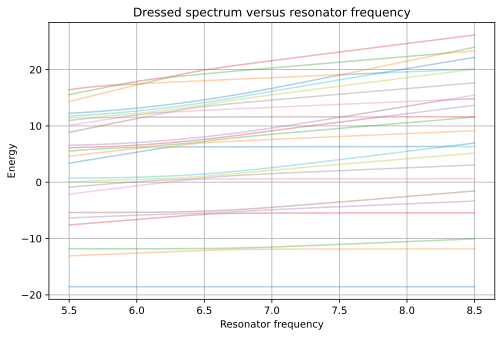

In [150]:
plt.figure(figsize=(8,5))
for k in range(evals_count):
    plt.plot(res_freqs, all_evals[:, k], alpha=0.35)
plt.xlabel("Resonator frequency")
plt.ylabel("Energy")
plt.title("Dressed spectrum versus resonator frequency")
plt.grid(True)
plt.show()

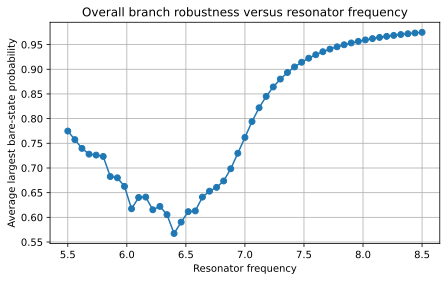

In [151]:
plt.figure(figsize=(7,4))
plt.plot(res_freqs, avg_max_prob, marker='o')
plt.xlabel("Resonator frequency")
plt.ylabel("Average largest bare-state probability")
plt.title("Overall branch robustness versus resonator frequency")
plt.grid(True)
plt.show()

Interpretation:

- higher average bare-state dominance means more robust branch identity,
- dips suggest parameter regions where branch mixing becomes more serious.

## Step 12. Optional extension: ParameterSweep with branch labeling

scqubits also supports branch labeling in parameter sweeps via
`ParameterSweep(..., labeling_scheme="LX")`.

This is useful once you already understand the manual diagnostics.

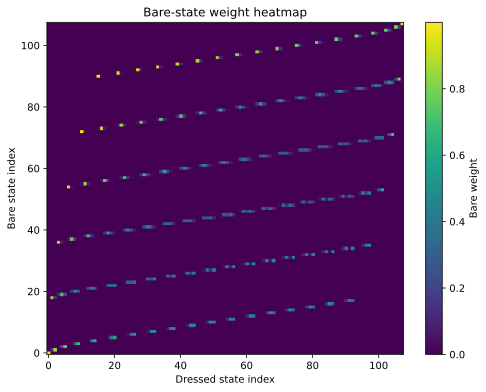

In [152]:
# Build bare-weight heatmap

vec_matrix = np.column_stack([evec.full().flatten() for evec in evecs])
prob_matrix = np.abs(vec_matrix)**2

plt.figure(figsize=(8,6))
plt.imshow(prob_matrix, aspect='auto', origin='lower')
plt.colorbar(label="Bare weight")
plt.xlabel("Dressed state index")
plt.ylabel("Bare state index")
plt.title("Bare-state weight heatmap")
plt.show()

# Using LX

# Staring from Step 8

In [4]:
EJ = 22.0
EC = 0.28
ng = 0.0

tmon = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=ng,
    ncut=45,
    truncated_dim=6
)

res = scq.Oscillator(
    E_osc=7.0,
    truncated_dim=18
)

In [5]:
hs = scq.HilbertSpace([tmon, res])

g = 0.11

hs.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True
)

In [14]:
evals_count = 80

evals, evecs = hs.eigensys(evals_count=evals_count)

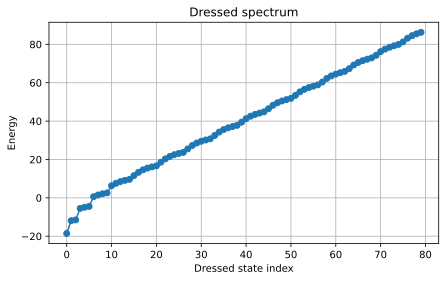

In [15]:
plt.figure(figsize=(7,4))
plt.plot(range(evals_count), evals, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Energy")
plt.title("Dressed spectrum")
plt.grid(True)
plt.show()

In [16]:
hs.generate_lookup(ordering="LX")

In [17]:
for k in range(12):
    print("dressed index", k, "→ bare label", hs.bare_index(k))

dressed index 0 → bare label (0, 0)
dressed index 1 → bare label (1, 0)
dressed index 2 → bare label (0, 1)
dressed index 3 → bare label (2, 0)
dressed index 4 → bare label (1, 1)
dressed index 5 → bare label (0, 2)
dressed index 6 → bare label (3, 0)
dressed index 7 → bare label (2, 1)
dressed index 8 → bare label (1, 2)
dressed index 9 → bare label (0, 3)
dressed index 10 → bare label (4, 0)
dressed index 11 → bare label (3, 1)


In [18]:
def branch_purity(level, photon_cut=12):

    purities = []
    states = []

    for n in range(photon_cut):

        k = hs.dressed_index((level, n))

        bare_vec = np.zeros(tmon.truncated_dim * res.truncated_dim)
        bare_vec[level*res.truncated_dim + n] = 1

        overlap = abs(np.vdot(evecs[k].full().flatten(), bare_vec))**2

        purities.append(overlap)
        states.append(k)

    return np.array(purities), np.array(states)

In [19]:
purity_g, states_g = branch_purity(0)
purity_e, states_e = branch_purity(1)

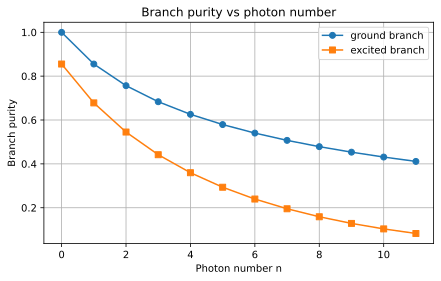

In [20]:
plt.figure(figsize=(7,4))

plt.plot(range(12), purity_g, marker='o', label="ground branch")
plt.plot(range(12), purity_e, marker='s', label="excited branch")

plt.xlabel("Photon number n")
plt.ylabel("Branch purity")
plt.title("Branch purity vs photon number")

plt.legend()
plt.grid(True)
plt.show()

In [21]:
res_freqs = np.linspace(5.5,8.5,51)

avg_branch_purity = []

In [23]:
for wr in res_freqs:

    res_tmp = scq.Oscillator(E_osc=wr, truncated_dim=18)
    hs_tmp = scq.HilbertSpace([tmon, res_tmp])

    hs_tmp.add_interaction(
        g_strength=g,
        op1=tmon.n_operator,
        op2=res_tmp.creation_operator,
        add_hc=True
    )

    evals_tmp, evecs_tmp = hs_tmp.eigensys(evals_count=60)

    hs_tmp.generate_lookup(ordering="LX")

    purities = []

    for n in range(10):

        k = hs_tmp.dressed_index((0,n))

        vec = evecs_tmp[k].full().flatten()

        bare_vec = np.zeros(tmon.truncated_dim * res_tmp.truncated_dim)
        bare_vec[n] = 1

        purities.append(abs(np.vdot(vec,bare_vec))**2)

    avg_branch_purity.append(np.mean(purities))

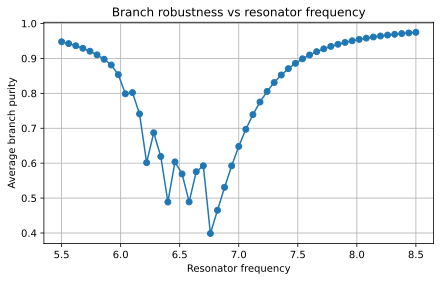

In [24]:
plt.figure(figsize=(7,4))

plt.plot(res_freqs, avg_branch_purity, marker='o')

plt.xlabel("Resonator frequency")
plt.ylabel("Average branch purity")
plt.title("Branch robustness vs resonator frequency")

plt.grid(True)
plt.show()

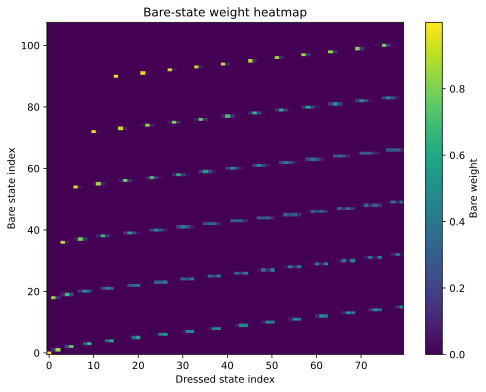

In [25]:
vec_matrix = np.column_stack([evec.full().flatten() for evec in evecs])

prob_matrix = np.abs(vec_matrix)**2

plt.figure(figsize=(8,6))
plt.imshow(prob_matrix, aspect='auto', origin='lower')
plt.colorbar(label="Bare weight")

plt.xlabel("Dressed state index")
plt.ylabel("Bare state index")

plt.title("Bare-state weight heatmap")
plt.show()